# Two-layer testing

This notebook tests the backend setup for a two-layer system with constant
extinction coefficient and varying single-scattering albedo.

In [1]:
# Documentation-specific setup, hidden from notebook output

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import seaborn as sns

sns.set_theme(style="ticks")

In [2]:
import eradiate
import matplotlib.pyplot as plt
import numpy as np
from eradiate.contexts import KernelContext

import eradiate_disort as ed
from eradiate_disort.testing import TestMode, cases
from eradiate_disort.testing.util import Result, disort_reshape_pplane

eradiate.set_mode("mono")

SPP = 1_000

In [3]:
# Dev-specific setup, hidden from notebook output

plt = TestMode.plt()
SPP = TestMode.spp(tutorial=1_000, test=10_000)

Text(0.5, 0, 'm')

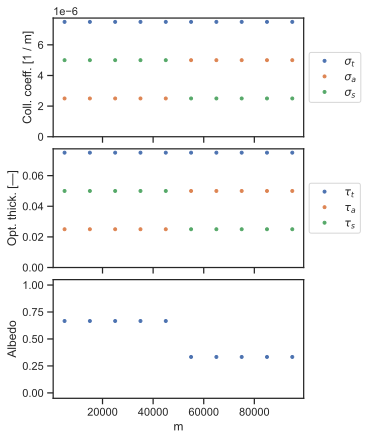

In [4]:
exp = cases.two_layers(sza=30.0)
ctx = KernelContext()
radprops = exp.atmosphere.eval_radprops(ctx.si, optional_fields=True)
zgrid = exp.geometry.zgrid
h = zgrid.layer_height.m_as("m")
tau_a = np.atleast_1d((radprops["sigma_a"] * h))
tau_s = np.atleast_1d((radprops["sigma_s"] * h))
tau_t = np.atleast_1d((radprops["sigma_t"] * h))

fig, axs = plt.subplots(3, 1, layout="constrained", figsize=(5, 6), sharex=True)

ax = axs[0]
with plt.rc_context({"lines.linestyle": "", "lines.marker": "."}):
    ax.plot(radprops["z_layer"], radprops["sigma_t"], label="$\\sigma_t$")
    ax.plot(radprops["z_layer"], radprops["sigma_a"], label="$\\sigma_a$")
    ax.plot(radprops["z_layer"], radprops["sigma_s"], label="$\\sigma_s$")

ax.set_ylabel(f"Coll. coeff. [{radprops['sigma_t'].attrs['units']}]")
ax.set_ylim(0, None)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

ax = axs[1]
with plt.rc_context({"lines.linestyle": "", "lines.marker": "."}):
    ax.plot(radprops["z_layer"], tau_t, label="$\\tau_t$")
    ax.plot(radprops["z_layer"], tau_a, label="$\\tau_a$")
    ax.plot(radprops["z_layer"], tau_s, label="$\\tau_s$")

ax.set_ylabel("Opt. thick. [—]")
ax.set_ylim(0, None)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

ax = axs[2]
with plt.rc_context({"lines.linestyle": "", "lines.marker": "."}):
    ax.plot(radprops["z_layer"], radprops["albedo"])
ax.set_ylabel("Albedo")
ax.set_ylim(-0.05, 1.05)

ax.set_xlabel(radprops["z_layer"].attrs["units"])

In [5]:
results = {}
_cases = {
    "rayleigh": {
        "has_absorption": False,
        "has_scattering": True,
        "surface_reflectance": 0.0,
    },
    "absorption": {
        "has_absorption": True,
        "has_scattering": False,
        "surface_reflectance": 1.0,
    },
    "full_black": {
        "has_absorption": True,
        "has_scattering": True,
        "surface_reflectance": 0.0,
    },
    "full_white": {
        "has_absorption": True,
        "has_scattering": True,
        "surface_reflectance": 1.0,
    },
}

for case_id, kwargs in _cases.items():
    print(f"Processing case {case_id!r}")
    if case_id in results:
        continue

    result = Result()

    exp = cases.two_layers(**kwargs, backend="mitsuba")
    result.mitsuba = eradiate.run(exp, spp=SPP)["radiance"].squeeze()

    exp = cases.two_layers(**kwargs, backend="disort")
    backend = ed.EradiateDisortBackend()
    result.disort = disort_reshape_pplane(backend.run(exp).sel(z=1e5))

    results[case_id] = result

Processing case 'rayleigh'
Processing case 'absorption'


Processing case 'full_black'
Processing case 'full_white'


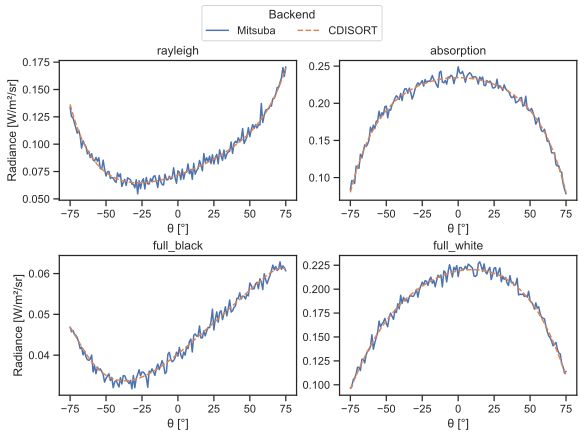

In [6]:
ncases = len(_cases)
ncols = 2
nrows = ncases // ncols + min(ncases % ncols, 1)

fig, axs = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), layout="constrained", squeeze=False
)

for i, case_id in enumerate(_cases.keys()):
    irow = i // ncols
    icol = i % ncols
    ax = axs.ravel()[i]
    result = results[case_id]

    ax.plot(result.mitsuba["vza"], result.mitsuba, label="Mitsuba" if i == 0 else None)
    ax.plot(
        result.disort["vza"],
        result.disort,
        label="CDISORT" if i == 0 else None,
        ls="--",
    )

    ax.set_title(case_id)
    ax.set_xlabel("θ [°]")
    if icol == 0:
        ax.set_ylabel("Radiance [W/m²/sr]")

else:
    while (i := i + 1) < axs.size:
        ax = axs.ravel()[i]
        ax.set_axis_off()

fig.legend(title="Backend", ncol=2, loc="outside upper center")

plt.show()